# Targeting Analysis

**Phase 6.** Which audience should receive which campaign?

This is Hillstrom's actual question, and it is the phase where portfolio projects
usually lose credibility — slicing until something looks significant is trivially
easy. Three things prevent that here, all fixed before any outcome was seen:

1. **The subgroup list is closed.** Eleven subgroups across four families, named
   in `PRE_REGISTRATION.md` §7. Nothing was added after seeing §5's results.
2. **Every estimate is reported beside its own MDE**, so an underpowered null
   reads as *inconclusive* rather than *no effect*.
3. **No differential claim without a formal interaction test.** Concluding that
   an effect differs because one subgroup is significant and another is not is a
   statistical error; §9.1 rules it out in advance.

> **Two amendments were written during this phase**, both disclosed in
> `PRE_REGISTRATION.md` §11.3 and both made *after* outcomes were observed by
> arm. The pre-registration turned out to be less complete than it appeared.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.db import get_engine
from src.inference import Q_SECONDARY, bh_correct, load_analysis_frame
from src.power import load_pooled_inputs, mde_proportion, n_required_proportion
from src.targeting import (
    campaign_dominance, interaction_tests, label_subgroups,
    mens_vs_womens_pooled, post_treatment_trap, shrink_estimates, subgroup_effects,
)

pd.set_option("display.width", 140)
engine = get_engine()
df = label_subgroups(load_analysis_frame(engine))
pooled = load_pooled_inputs(engine)

## 1. Subgroup effects, each beside its own MDE

Estimated from a saturated `conversion ~ treatment × subgroup` model per family,
with HC2 robust errors (see Amendment 1). BH correction at q = 0.10 across all
22 tests, as §9 specifies.

In [2]:
eff = subgroup_effects(df)
eff["mde_pp"] = eff.n_per_arm.apply(lambda n: mde_proportion(pooled.p_conversion, int(n)))
reject, p_adj = bh_correct(eff.p_value.tolist(), Q_SECONDARY)
eff["p_adj"], eff["bh_significant"] = p_adj, reject

eff[["family", "level", "contrast", "n", "effect_pp",
     "ci_low_pp", "ci_high_pp", "mde_pp", "bh_significant"]].round(3)

,family,level,contrast,n,effect_pp,ci_low_pp,ci_high_pp,mde_pp,bh_significant
0,prior purchase,both,Mens E-Mail vs Control,6448,1.499,0.736,2.263,0.809,True
1,prior purchase,mens only,Mens E-Mail vs Control,28818,0.601,0.341,0.861,0.382,True
2,prior purchase,womens only,Mens E-Mail vs Control,28734,0.572,0.320,0.825,0.383,True
3,prior purchase,both,Womens E-Mail vs Control,6448,0.533,-0.120,1.186,0.809,False
4,prior purchase,mens only,Womens E-Mail vs Control,28818,0.063,-0.152,0.278,0.382,False
5,prior purchase,womens only,Womens E-Mail vs Control,28734,0.511,0.264,0.759,0.383,True
6,newbie,established,Mens E-Mail vs Control,31856,0.621,0.342,0.899,0.364,True
7,newbie,newbie,Mens E-Mail vs Control,32144,0.740,0.509,0.970,0.362,True
8,newbie,established,Womens E-Mail vs Control,31856,0.093,-0.149,0.336,0.364,False
9,newbie,newbie,Womens E-Mail vs Control,32144,0.527,0.314,0.740,0.362,True


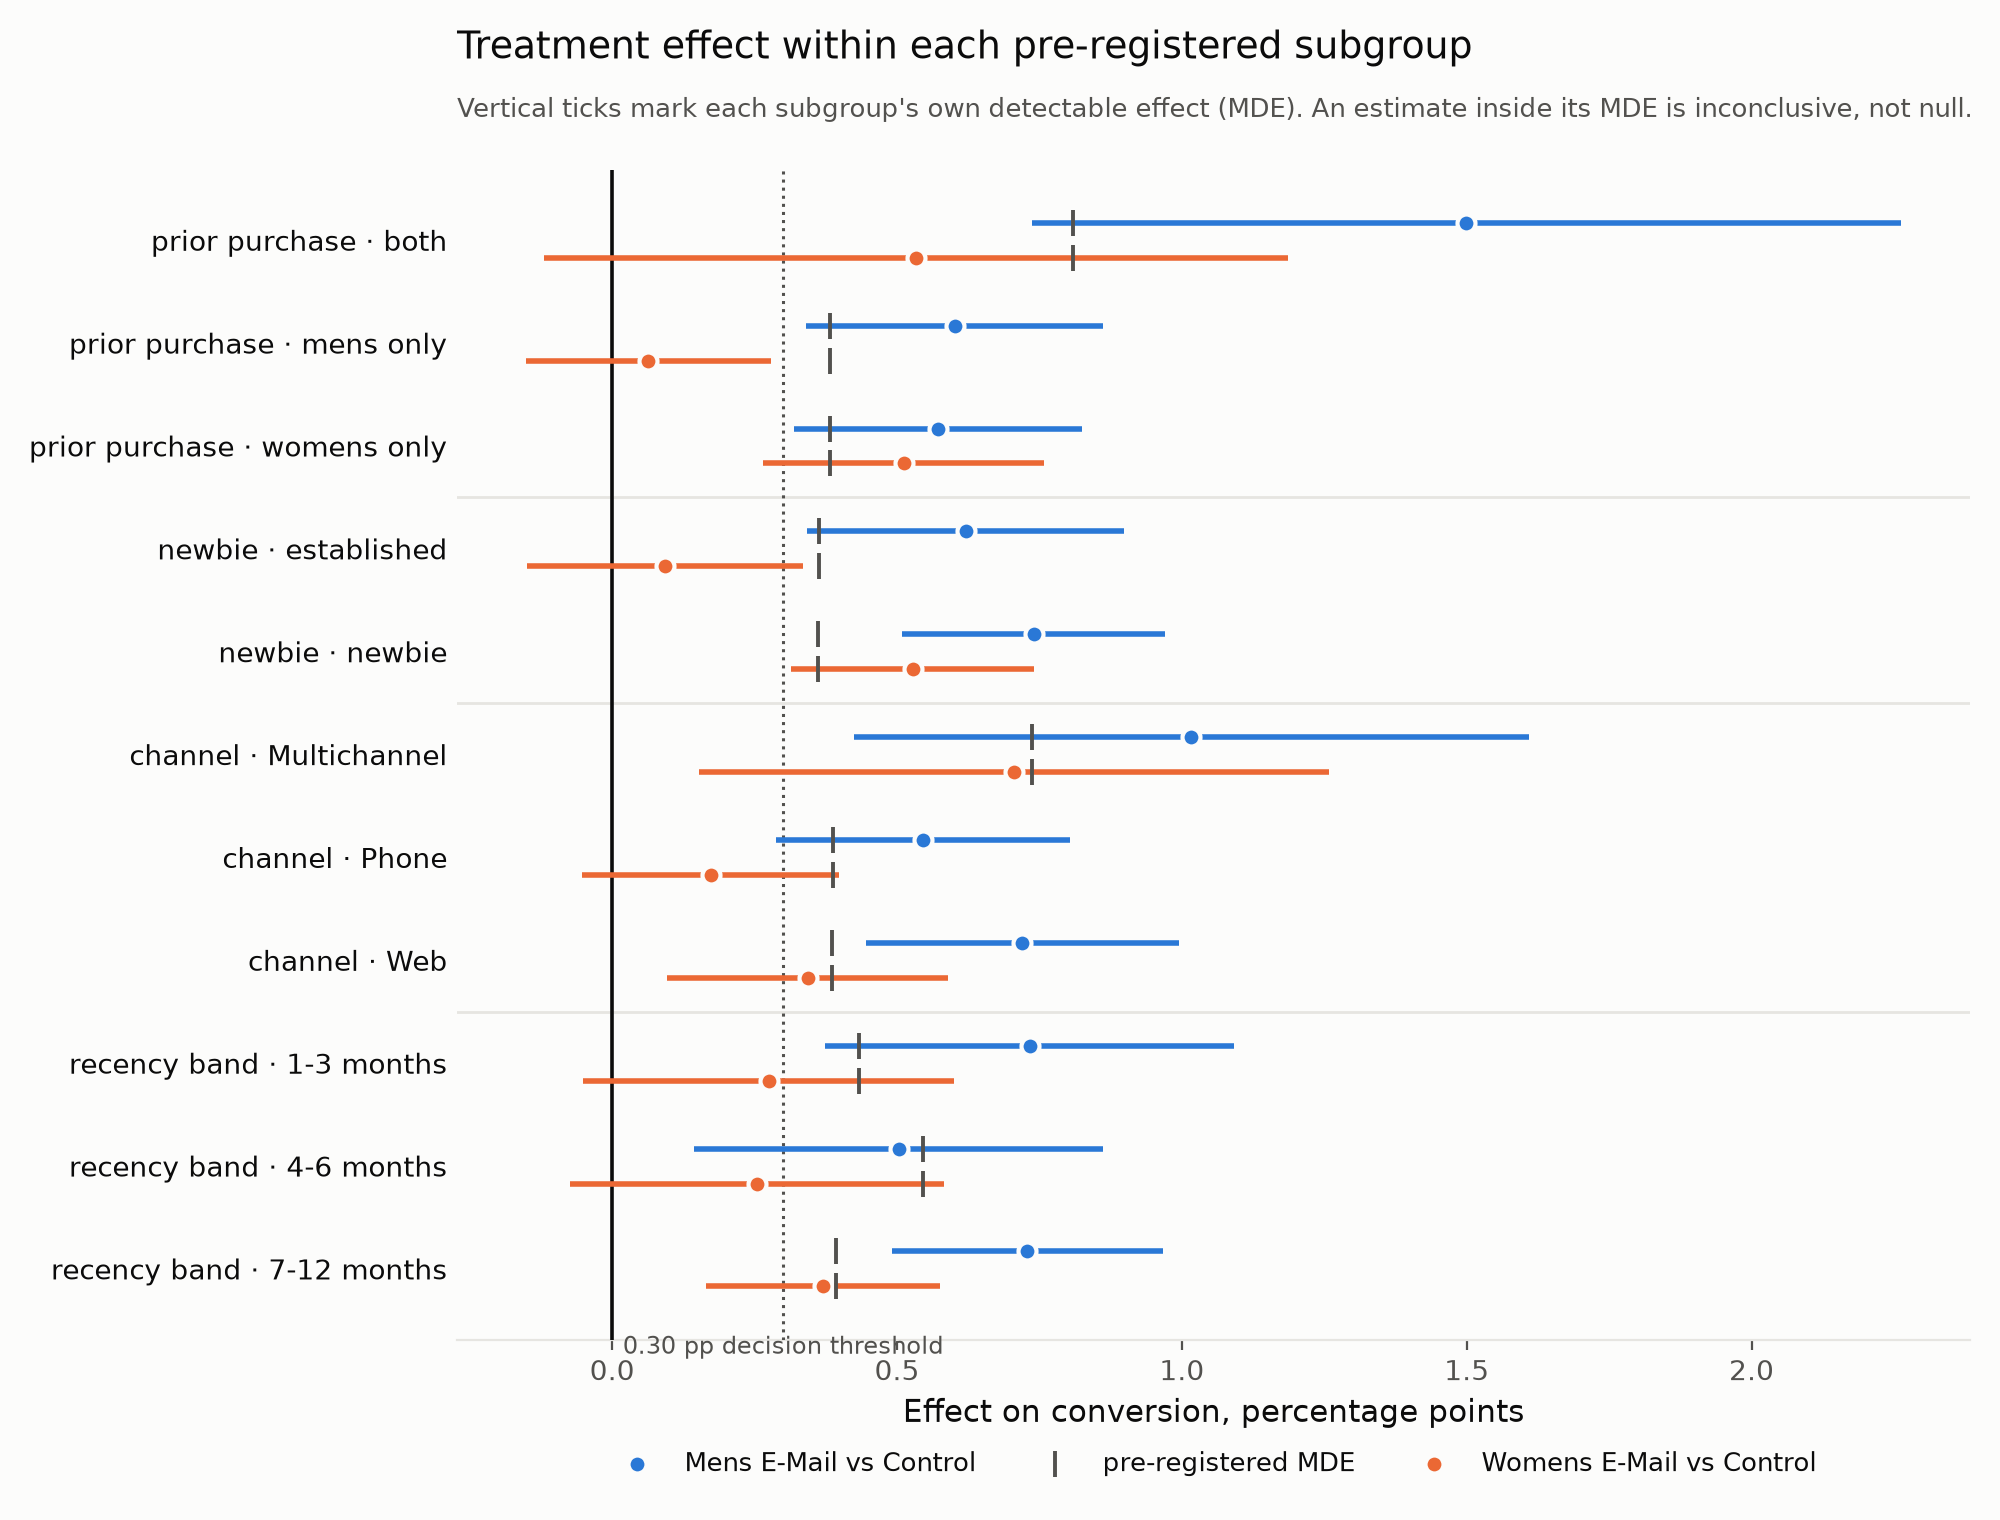

In [3]:
from IPython.display import Image
from src.db import PROJECT_ROOT
Image(str(PROJECT_ROOT / "figures" / "subgroup_effects.png"), width=940)

A clear asymmetry, visible before any test is run:

- **The Mens campaign works everywhere.** All 11 of its subgroup effects are
  BH-significant, ranging from +0.50 pp to +1.50 pp.
- **The Womens campaign is selective.** It is indistinguishable from zero for
  `mens only` buyers (+0.06 pp), for `established` customers (+0.09 pp), and for
  `Phone` customers (+0.17 pp).

Resist the obvious inference. "Significant here, not there" is *not* evidence
that the effect differs — that is precisely the error §9.1 forbids. The two
subgroups have different sample sizes and different standard errors, so
different significance verdicts are expected even under an identical true
effect. The test on the difference itself comes next.

## 2. Interaction tests — the only valid basis for a targeting claim

Joint Wald test on each family's interaction block, run separately per campaign
because §10 condition 2 is specified per (campaign × covariate).

In [4]:
inter = interaction_tests(df)
ireject, ip_adj = bh_correct(inter.p_value.tolist(), Q_SECONDARY)
inter["p_adj"], inter["bh_significant"] = ip_adj, ireject
inter.round(4)

,family,contrast,df_num,f_stat,p_value,p_adj,bh_significant
0,prior purchase,Mens E-Mail vs Control,2,2.6146,0.0732,0.1952,False
1,prior purchase,Womens E-Mail vs Control,2,3.9227,0.0198,0.0792,True
2,newbie,Mens E-Mail vs Control,1,0.4165,0.5187,0.6352,False
3,newbie,Womens E-Mail vs Control,1,6.9541,0.0084,0.0669,True
4,channel,Mens E-Mail vs Control,2,1.1610,0.3132,0.5011,False
5,channel,Womens E-Mail vs Control,2,1.6936,0.1839,0.3677,False
6,recency band,Mens E-Mail vs Control,2,0.5874,0.5558,0.6352,False
7,recency band,Womens E-Mail vs Control,2,0.2281,0.7960,0.7960,False


**Two interactions survive correction, and both belong to the Womens campaign:**

| Family | Campaign | F | p | BH-adj p |
|---|---|---|---|---|
| prior purchase | Womens | 3.92 | 0.0198 | **0.0792** ✓ |
| newbie | Womens | 6.95 | 0.0084 | **0.0669** ✓ |

**No Mens interaction is significant.** Its effect is statistically
indistinguishable across every family tested — consistent with a campaign that
simply works for everyone.

This is a genuine heterogeneous treatment effect, established the correct way:
the Womens campaign's effect *does* depend on whether a customer previously
bought womens merchandise, and on whether they are new. Six of the eight
interaction tests are null, which is exactly what §9.1 predicted — interactions
need roughly four times the sample of main effects.

## 3. Applying the decision rule — and finding a hole in it

§10 requires all four conditions: pre-registered subgroup, significant
interaction, CI excluding zero after BH, and a point estimate ≥ 0.30 pp.

In [5]:
sig_inter = {(r.family, r.contrast) for _, r in inter.iterrows() if r.bh_significant}
eff["interaction_sig"] = [(r.family, r.contrast) in sig_inter for _, r in eff.iterrows()]
eff["passes_rule"] = (eff.interaction_sig & eff.bh_significant
                      & (eff.effect_pp >= 0.30))
eff.loc[eff.passes_rule, ["family", "level", "contrast", "effect_pp",
                          "ci_low_pp", "ci_high_pp"]].round(3)

,family,level,contrast,effect_pp,ci_low_pp,ci_high_pp
5,prior purchase,womens only,Womens E-Mail vs Control,0.511,0.264,0.759
9,newbie,newbie,Womens E-Mail vs Control,0.527,0.314,0.740


Applied mechanically, the rule returns **two passes**, both for the Womens
campaign: within `prior purchase = womens only` and within `newbie = newbie`.

Taken at face value that reads as a targeting recommendation: *send the Womens
campaign to womens-merchandise buyers and to new customers.*

**It would be wrong.**

In [6]:
dom = campaign_dominance(eff)
dom.round(3)

,family,level,mens_pp,womens_pp,mens_minus_womens_pp,womens_better
0,channel,Multichannel,1.017,0.705,0.312,False
1,channel,Phone,0.546,0.173,0.374,False
2,channel,Web,0.720,0.343,0.377,False
3,newbie,established,0.621,0.093,0.528,False
4,newbie,newbie,0.740,0.527,0.212,False
5,prior purchase,both,1.499,0.533,0.966,False
6,prior purchase,mens only,0.601,0.063,0.538,False
7,prior purchase,womens only,0.572,0.511,0.061,False
8,recency band,1-3 months,0.733,0.275,0.458,False
9,recency band,4-6 months,0.503,0.254,0.249,False


### The rule never compares the campaigns to each other

**The Mens campaign has a larger point estimate in all 11 subgroups — including
both subgroups where the Womens campaign "passes".** In `womens only` it is
+0.572 pp against +0.511 pp; in `newbie`, +0.740 pp against +0.527 pp.

§10 conditions 1–4 test campaign X against **control**. They never test X against
the **other campaign**. So a campaign can satisfy every condition in a subgroup
where the alternative is strictly better, and the rule still says "recommend X".

This is disclosed as **Amendment 2** rather than fixed by rewriting the rule. The
rule's output is reported exactly as produced; the gap is reported beside it; and
the business recommendation follows the evidence, not the literal output.

Note what is *not* being done here: eleven within-subgroup campaign-vs-campaign
significance tests were not pre-registered, and adding them now — after seeing
which direction they would point — is the exact move this project exists to rule
out. Only point estimates are shown. A confirmatory test is the correct next
step.

In [7]:
mvw = mens_vs_womens_pooled(df)
print(f"Pooled Mens vs Womens (pre-registered secondary family)")
print(f"  {mvw['effect_pp']:+.3f} pp  "
      f"[{mvw['ci_low_pp']:+.3f}, {mvw['ci_high_pp']:+.3f}]   p = {mvw['p_value']:.2e}")

Pooled Mens vs Womens (pre-registered secondary family)
  +0.369 pp  [+0.174, +0.564]   p = 2.06e-04


The pooled head-to-head confirms it: Mens beats Womens by **+0.369 pp**
(95% CI +0.174 to +0.564). This contrast *was* pre-registered, in the §9
secondary family.

## 4. Winner's curse

If a subgroup effect is reported *because* it was the largest, its estimate is
biased upward — selection guarantees it. §10.2 pre-commits to reporting this and
to sizing any follow-up on a **shrunk** estimate.

In [8]:
sh = shrink_estimates(eff)
for contrast, g in sh.groupby("contrast"):
    best = g.loc[g.effect_pp.idxmax()]
    n_raw = n_required_proportion(pooled.p_conversion, abs(best.effect_pp))
    n_shr = n_required_proportion(pooled.p_conversion, abs(best.effect_shrunk_pp))
    print(f"{contrast}")
    print(f"  winner            {best.family} = {best.level}")
    print(f"  raw estimate      {best.effect_pp:+.3f} pp")
    print(f"  shrunk estimate   {best.effect_shrunk_pp:+.3f} pp")
    print(f"  follow-up n/arm   {n_raw:,.0f} on raw  ->  {n_shr:,.0f} on shrunk "
          f"({n_shr / n_raw:.1f}x)\n")

Mens E-Mail vs Control
  winner            prior purchase = both
  raw estimate      +1.499 pp
  shrunk estimate   +0.914 pp
  follow-up n/arm   625 on raw  ->  1,683 on shrunk (2.7x)

Womens E-Mail vs Control
  winner            channel = Multichannel
  raw estimate      +0.705 pp
  shrunk estimate   +0.390 pp
  follow-up n/arm   2,825 on raw  ->  9,235 on shrunk (3.3x)



The largest Mens subgroup effect (+1.50 pp, `prior purchase = both`) shrinks to
**+0.91 pp**. That is not a rounding matter: a confirmatory test sized on the raw
winner would need 625 per arm, while the shrunk estimate demands **1,683** —
**2.7× larger**. Sizing on the unshrunk winner would leave a follow-up badly
underpowered, and it would fail for reasons that had nothing to do with the
campaign.

The `both` cell is also the smallest subgroup in the study (n = 6,448, MDE
0.81 pp), which is exactly where selection bias bites hardest — noisy cells
produce extreme estimates, and extreme estimates get selected.

## 5. The post-treatment trap, demonstrated deliberately

`CLAUDE.md` asks for a demonstration of what happens when you segment on a
**post-treatment** variable. Below is that error, run on purpose and clearly
labelled. **These numbers are not causal effects.**

In [9]:
post_treatment_trap(df).round(3)

,conditioned on,contrast,n_treatment,n_control,rate_treatment_pct,rate_control_pct,apparent_effect_pp
0,visit = 1,Mens E-Mail vs Control,3894,2262,6.857,5.393,1.463
1,visit = 0,Mens E-Mail vs Control,17413,19044,0.000,0.000,0.000
2,visit = 1,Womens E-Mail vs Control,3238,2262,5.837,5.393,0.443
3,visit = 0,Womens E-Mail vs Control,18149,19044,0.000,0.000,0.000


Conditioning on `visit` produces two absurdities.

**Among visitors, the Mens "effect" is +1.46 pp** — more than double the true
+0.675 pp. **Among non-visitors it is exactly 0.000 pp**, in every arm, because
this dataset's funnel makes `conversion = 1` impossible without `visit = 1`. The
"effect" is mechanically zero by construction.

Why this breaks: `visit` is *itself caused by treatment* (+7.6 pp for Mens). The
moment you condition on it, the randomisation is gone. Control visitors are
people motivated enough to arrive with no e-mail at all; treated visitors include
marginal people the e-mail pulled in, who were always less likely to buy. The
contrast mixes the treatment effect with that selection difference, and **no
amount of covariate adjustment separates them** — the problem is the conditioning
itself, not omitted variables.

The tell is available *before* looking at any result: `visit` is measured after
treatment. That is the whole test. Every subgroup in §7 is defined from
pre-treatment covariates for exactly this reason.

## Verdict

**No differential targeting is warranted. Send the Mens campaign to everyone.**

The reasoning, in order:

1. **A real heterogeneous effect exists**, and it was established properly: the
   Womens campaign's effect genuinely depends on prior purchase history and on
   customer tenure, confirmed by interaction tests surviving BH correction.
2. **It does not change what to do.** The Mens campaign has a larger point
   estimate in all 11 subgroups, and beats the Womens campaign by +0.369 pp
   pooled. There is no audience for which the Womens campaign is the better
   choice.
3. **The decision rule's two "passes" are artefacts of its structure**, not
   findings. It validates against control and never against the alternative arm
   (Amendment 2).

What would change this conclusion: a subgroup where the Womens campaign
genuinely beats the Mens campaign. None was found, and the study was not
designed to find one — a within-subgroup campaign-vs-campaign comparison was
never pre-registered, and interaction tests are underpowered here regardless.

**Recommended next step:** a confirmatory two-arm test of Mens vs Womens within
`womens only` buyers, where the gap is narrowest (+0.061 pp) and a genuine
reversal is most plausible. Size it on shrunk estimates, not on the observed
winner.